# G3 rep2 — Integrated Analysis

Six panels covering the full training dynamics of `DiT_mini_parity_N4096_D36_G3_even_rep2`:

1. **Sample raster** — per-sample 4-state trajectory
2. **Transition matrix** — transition counts and probabilities over a key window
3. **Vector field / score landscape** — at ep 49, 14251, 119377, 492388 (σ=1.0)
4. **DSM loss σ∈[0.2,2.0] vs training step** — train/test/random
5. **DSM loss vs σ at key checkpoints** — log-log curves
6. **Attractor basin profiles** — three directions, three epochs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

PROJECT_ROOT = "/n/home12/binxuwang/Github/DiffusionAttnConsistency"
sys.path.insert(0, PROJECT_ROOT)

# Publication-quality defaults
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 120

# ── Imports ───────────────────────────────────────────────────────
from core.vector_field_lib import (
    load_training_data, load_model, eval_field_on_grid,
    make_plane_hash, project_to_basis,
    plot_vector_field_2d, plot_denoiser_target_2d, DEFAULT_SAVEROOT,
)
from core.basin_lib import basin_plot_profiles
from scripts.plot_sample_evolution import (
    load_data, plot_raster, compute_transition_matrix,
    plot_transition_heatmap_both,
)
from scripts.plot_sigma_loss_evolution import (
    load_sigma_data, bin_mean, _draw_sigma_panel, SIGMA_BINS,
)

%matplotlib inline
print('Imports OK')

Imports OK


In [66]:

# ── Config ────────────────────────────────────────────────────────
EXP_NAME  = "DiT_mini_parity_N4096_D36_G3_even_rep2"
SAVEROOT  = DEFAULT_SAVEROOT
EXP_DIR   = os.path.join(SAVEROOT, EXP_NAME)
FIGDIR    = os.path.join(PROJECT_ROOT, "figures", "RuleMemDeepDive", "DiT_mini_G3_N4096_rep2")
os.makedirs(FIGDIR, exist_ok=True)

# Vector field checkpoints (use cached σ=1.0)
VF_EPOCHS  = [49, 14251, 119377, 492388]
VF_SIGMA   = 0.5
VF_CACHE   = os.path.join(EXP_DIR, "vector_field_cache")
PLANE_HASH = "191059703a35"   # sha1 prefix of (x_a, x_b, x_c) anchors
RANGE_TAG  = "a-1.75_3.75"
NGRID      = 50

# Basin checkpoints
BASIN_EPOCHS = [7017, 20309, 492388]
BASIN_SIGMA  = 0.5
BASIN_N      = 30
BASIN_CACHE  = os.path.join(EXP_DIR, "basin_analysis", "line_cache")
BASIN_LABELS = {
    7017:   "ep 7017 (pre rule-learning)",
    20309:  "ep 20309 (post rule-learning)",
    492388: "ep 492388 (memorization onset)",
}
BASIN_COLORS = {7017: 'C0', 20309: 'C1', 492388: 'C2'}

# sigma_loss which_idx: [ep49, ep14251, ep119377, ep492388]
SIGMA_LOSS_IDX = [10, 26, 32, 36]

def savefig_both(fig, name):
    """Save PNG + PDF with fonttype 42."""
    for ext in ('.png', '.pdf'):
        path = os.path.join(FIGDIR, name + ext)
        fig.savefig(path, dpi=600, bbox_inches='tight')
    print(f"  Saved: {name}.png/pdf")

print(f"FIGDIR: {FIGDIR}")


FIGDIR: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/RuleMemDeepDive/DiT_mini_G3_N4096_rep2


## Panel 1 — Sample Raster

  Saved: 01_sample_raster_mem_order_nolegend.png/pdf


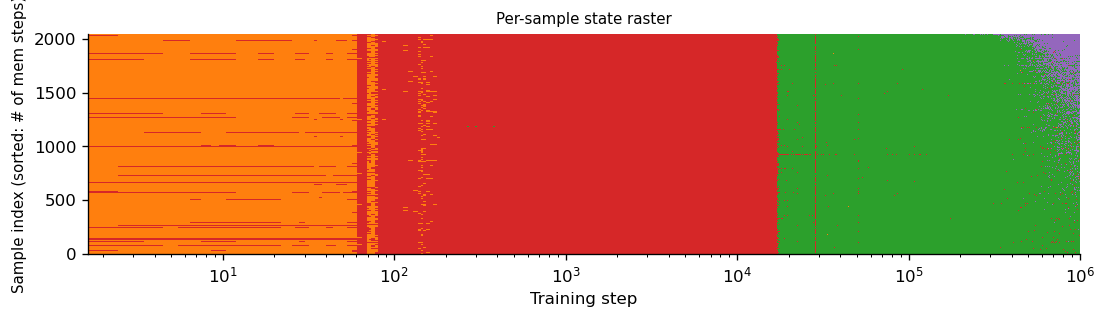

In [68]:
from scripts.plot_sample_evolution import plot_raster_custom_order
d = load_data(EXP_NAME, SAVEROOT)
fig = plot_raster_custom_order(d, sort_idxs=np.argsort(d["is_mem"].sum(axis=0)),
                               sort_str="# of mem steps", backend="pcolormesh", legend=False)
fig.set_size_inches(9, 2.25)
savefig_both(fig, '01_sample_raster_mem_order_nolegend')
fig.show()

In [69]:
fig.axes[0].get_xlim()

(np.float64(1.632993161855452), np.float64(1000465.3231936209))

  Saved: 01_sample_stacked_area_mem_order.png/pdf


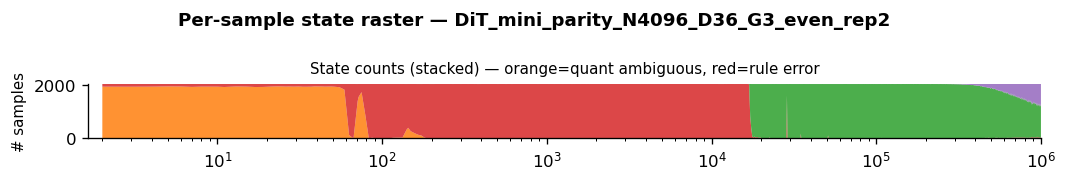

In [50]:
from scripts.plot_sample_evolution import build_state, sort_state, pcolormesh_edges, STATE_INFO

def plot_stacked_area(d, exp_name, figdir=None, save=True):
    epochs    = d['epochs']
    is_valid  = d['is_valid']
    is_mem    = d['is_mem']
    has_ambig = d['has_ambiguous']
    T, N      = is_valid.shape

    state = build_state(is_valid, is_mem, has_ambig)
    state_sorted, sort_key, final_state = sort_state(state, is_valid, is_mem)

    x_lin   = pcolormesh_edges(epochs)
    y_edges = np.arange(N + 1)

    cmap = mcolors.ListedColormap([info[2] for info in STATE_INFO])
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    counts = np.stack([(state == s).sum(axis=1) for s, *_ in STATE_INFO], axis=1)

    fig, axes = plt.subplots(1, 1, figsize=(9, 1.5),)
    fig.suptitle(f"Per-sample state raster — {exp_name}", fontsize=11, fontweight='bold')
    # Panel 1: stacked area
    ax = axes#[0]
    ax.stackplot(epochs + 1,
                 counts[:,0], counts[:,1], counts[:,2], counts[:,3],
                 labels=[info[1] for info in STATE_INFO],
                 colors=[info[2] for info in STATE_INFO], alpha=0.85)
    ax.set_ylim(0, N); ax.set_ylabel('# samples', fontsize=9)
    ax.set_xscale('log'); ax.set_xlim(x_lin[0], x_lin[-1])
    # ax.legend(fontsize=8, loc='upper left', ncol=2); ax.grid(alpha=0.2)
    ax.set_title('State counts (stacked) — orange=quant ambiguous, red=rule error', fontsize=9)
    plt.tight_layout()
    return fig

d = load_data(EXP_NAME, SAVEROOT)
fig = plot_stacked_area(d, EXP_NAME, figdir=FIGDIR, save=False)
savefig_both(fig, '01_sample_stacked_area_mem_order')
fig.show()

  Saved: 01_sample_raster.png/pdf


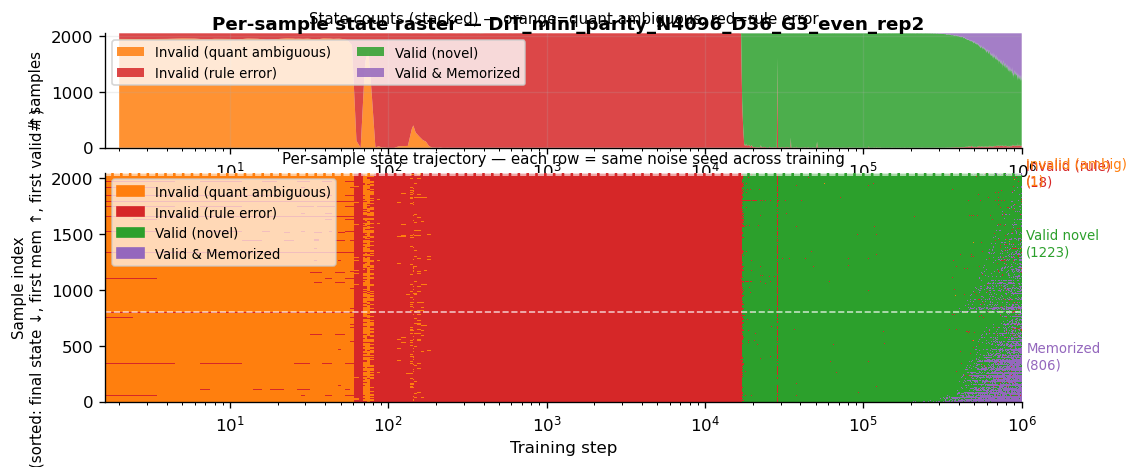

In [ ]:
# def plot_raster(d, exp_name, figdir=None, save=True):
#     epochs    = d['epochs']
#     is_valid  = d['is_valid']
#     is_mem    = d['is_mem']
#     has_ambig = d['has_ambiguous']
#     T, N      = is_valid.shape

#     state = build_state(is_valid, is_mem, has_ambig)
#     state_sorted, sort_key, final_state = sort_state(state, is_valid, is_mem)

#     x_lin   = pcolormesh_edges(epochs)
#     y_edges = np.arange(N + 1)

#     cmap = mcolors.ListedColormap([info[2] for info in STATE_INFO])
#     norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

#     counts = np.stack([(state == s).sum(axis=1) for s, *_ in STATE_INFO], axis=1)

#     fig, axes = plt.subplots(2, 1, figsize=(13, 10),
#                               gridspec_kw={'height_ratios': [1.5, 3]})
#     fig.suptitle(f"Per-sample state raster — {exp_name}", fontsize=11, fontweight='bold')

#     # Panel 1: stacked area
#     ax = axes[0]
#     ax.stackplot(epochs + 1,
#                  counts[:,0], counts[:,1], counts[:,2], counts[:,3],
#                  labels=[info[1] for info in STATE_INFO],
#                  colors=[info[2] for info in STATE_INFO], alpha=0.85)
#     ax.set_ylim(0, N); ax.set_ylabel('# samples', fontsize=9)
#     ax.set_xscale('log'); ax.set_xlim(x_lin[0], x_lin[-1])
#     ax.legend(fontsize=8, loc='upper left', ncol=2); ax.grid(alpha=0.2)
#     ax.set_title('State counts (stacked) — orange=quant ambiguous, red=rule error', fontsize=9)

#     # Panel 2: raster
#     ax = axes[1]
#     ax.pcolormesh(x_lin, y_edges, state_sorted.T.astype(float),
#                   cmap=cmap, norm=norm, rasterized=True)
#     ax.set_xscale('log')
#     ax.set_xlim(x_lin[0], x_lin[-1]); ax.set_ylim(0, N)
#     ax.set_xlabel('Training step', fontsize=10)
#     ax.set_ylabel('Sample index\n(sorted: final state ↓, first mem ↑, first valid ↑)', fontsize=9)
#     ax.set_title('Per-sample state trajectory — each row = same noise seed across training', fontsize=9)

#     # Dividers and annotations
#     y_cursor = 0
#     for s_id, lbl, col in [(3,'Memorized','#9467bd'), (2,'Valid novel','#2ca02c'),
#                              (1,'Invalid (rule)','#d62728'), (0,'Invalid (ambig)','#ff7f0e')]:
#         count = int((final_state[sort_key] == s_id).sum())
#         ax.axhline(y_cursor + count, color='white', lw=1.0, ls='--', alpha=0.7)
#         if count > 0:
#             ax.annotate(f'{lbl}\n({count})',
#                         xy=(1.005, (y_cursor + count / 2) / N), xycoords='axes fraction',
#                         fontsize=8, color=col, va='center')
#         y_cursor += count

#     legend_els = [Patch(color=info[2], label=info[1]) for info in STATE_INFO]
#     ax.legend(handles=legend_els, fontsize=8, loc='upper left', framealpha=0.7)

#     plt.tight_layout()
#     if save:
#         savefig(fig, figdir, 'state_raster_4state', exp_name)
#         plt.close(fig)
#         print(f"  Saved: state_raster_4state")
#     return fig

d = load_data(EXP_NAME, SAVEROOT)
fig = plot_raster(d, EXP_NAME, figdir=FIGDIR, save=False)
fig.set_size_inches(9, 4)
gs = fig.axes[0].get_gridspec()
# gs.set_width_ratios([1, 3])
gs.set_height_ratios([1, 4])
fig.canvas.draw()  # or plt.draw()
savefig_both(fig, '01_sample_raster')
plt.show()

In [28]:
fig.axes[0].get_gridspec()

GridSpec(2, 1, height_ratios=[1, 4])

## Panel 2 — Transition Heatmap

Show both unnormalized (count) and normalized (probability) heatmaps summed over a key window.
Two windows: early training (ep 1k–20k, rule-learning transition) and late (ep 20k–500k, memorization onset).

/n/home12/binxuwang/Github/DiffusionAttnConsistency/scripts/plot_sample_evolution.py:147: RuntimeWarning: invalid value encountered in divide
  T_prob[:, i, j]  = np.where(src_pop > 0, cnt / src_pop, 0.0)


  Saved: 02_transition_heatmap_rule_learning.png/pdf


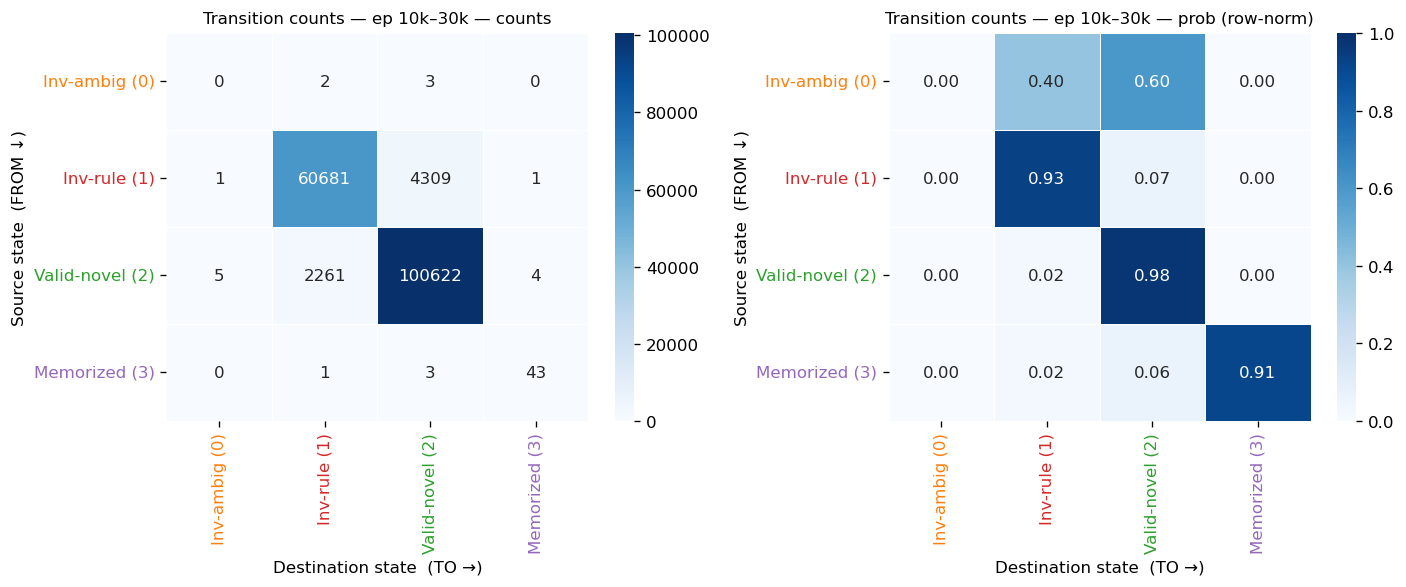

  Saved: 02_transition_heatmap_memorization.png/pdf


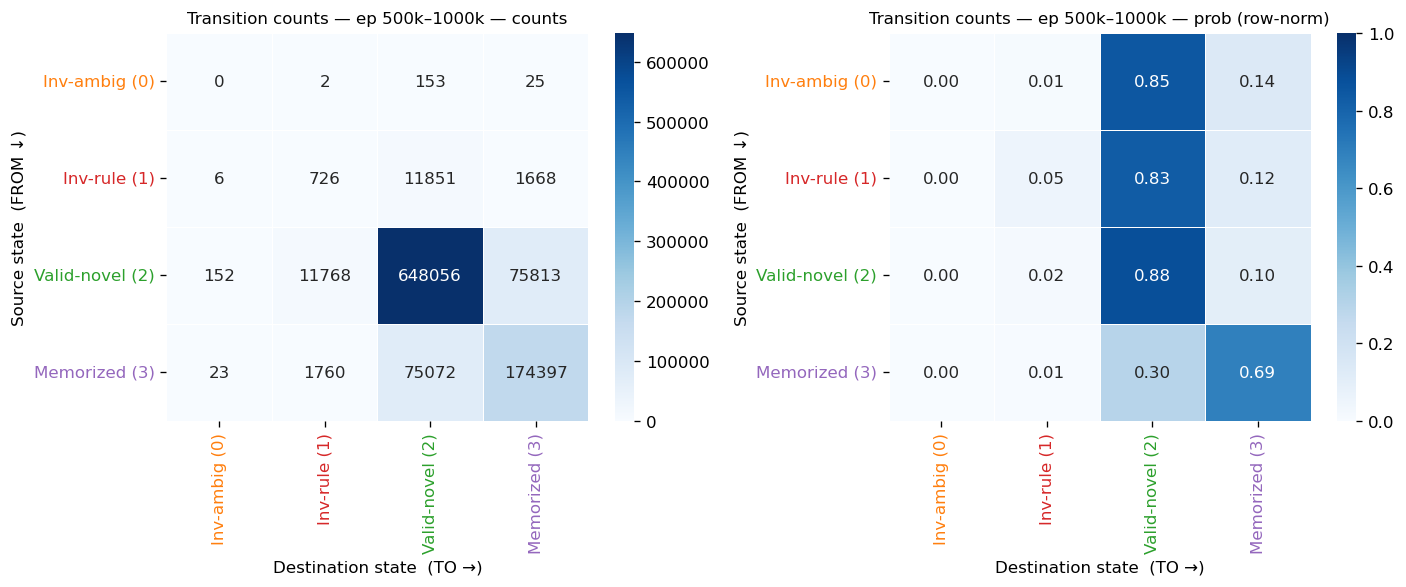

In [5]:
T_count, T_prob, epochs_ev, ep_mid = compute_transition_matrix(d)

for win_label, win_lo, win_hi in [
    ('rule_learning',   10_000,   30_000),
    ('memorization', 500_000, 1_000_000),
]:
    mask = (ep_mid >= win_lo) & (ep_mid < win_hi)
    T_win = T_count[mask].sum(axis=0)   # (4,4) summed counts
    fig = plot_transition_heatmap_both(
        T_win,
        title=f"Transition counts — ep {win_lo//1000}k–{win_hi//1000}k"
    )
    savefig_both(fig, f'02_transition_heatmap_{win_label}')
    plt.show()

### Panel 3: landscape plot

L_ab=2.828  L_perp=1.414
Markers: x_a=(0,0)  x_b=(2.83,0)  x_c=(1.41,1.41)  x_d=(1.41,-1.41)
  Saved: 03_vector_field_ckpt_000049.png/pdf


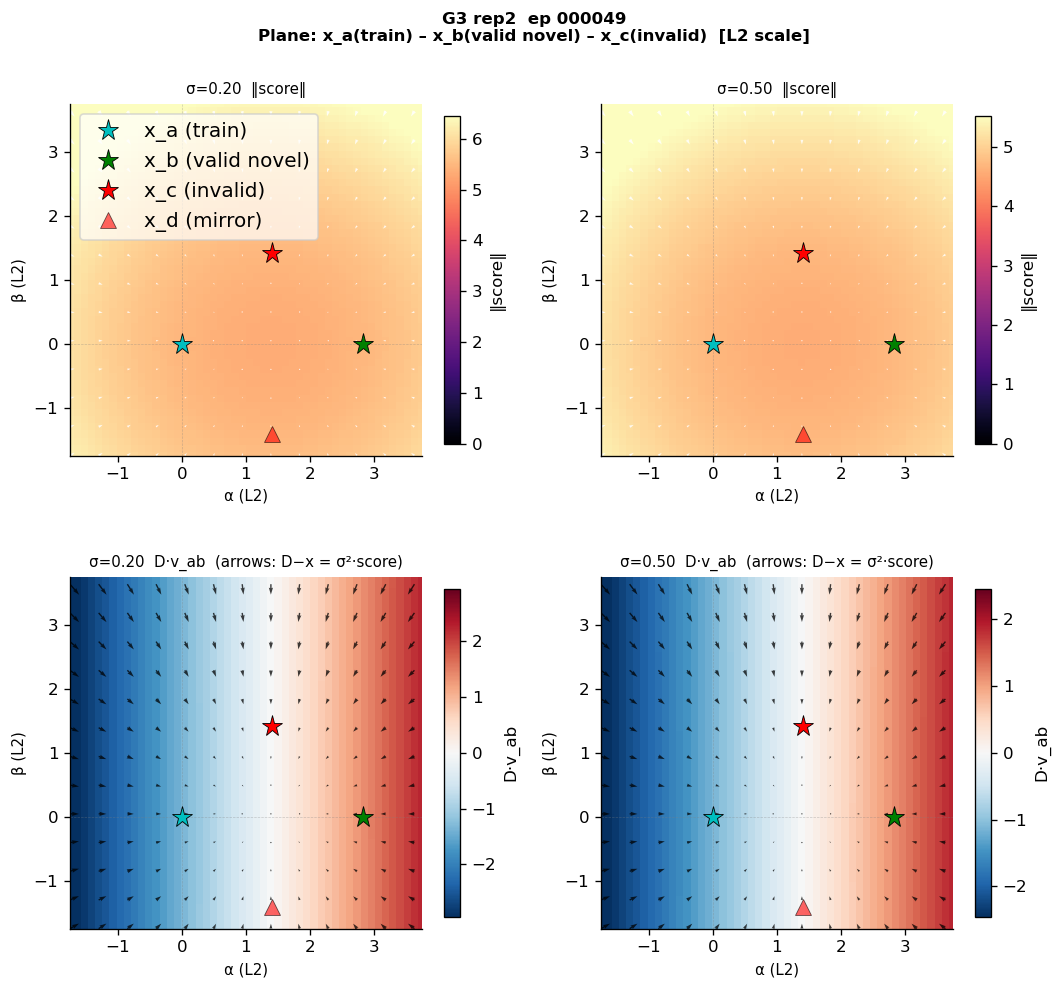

  Saved: 03_vector_field_ckpt_014251.png/pdf


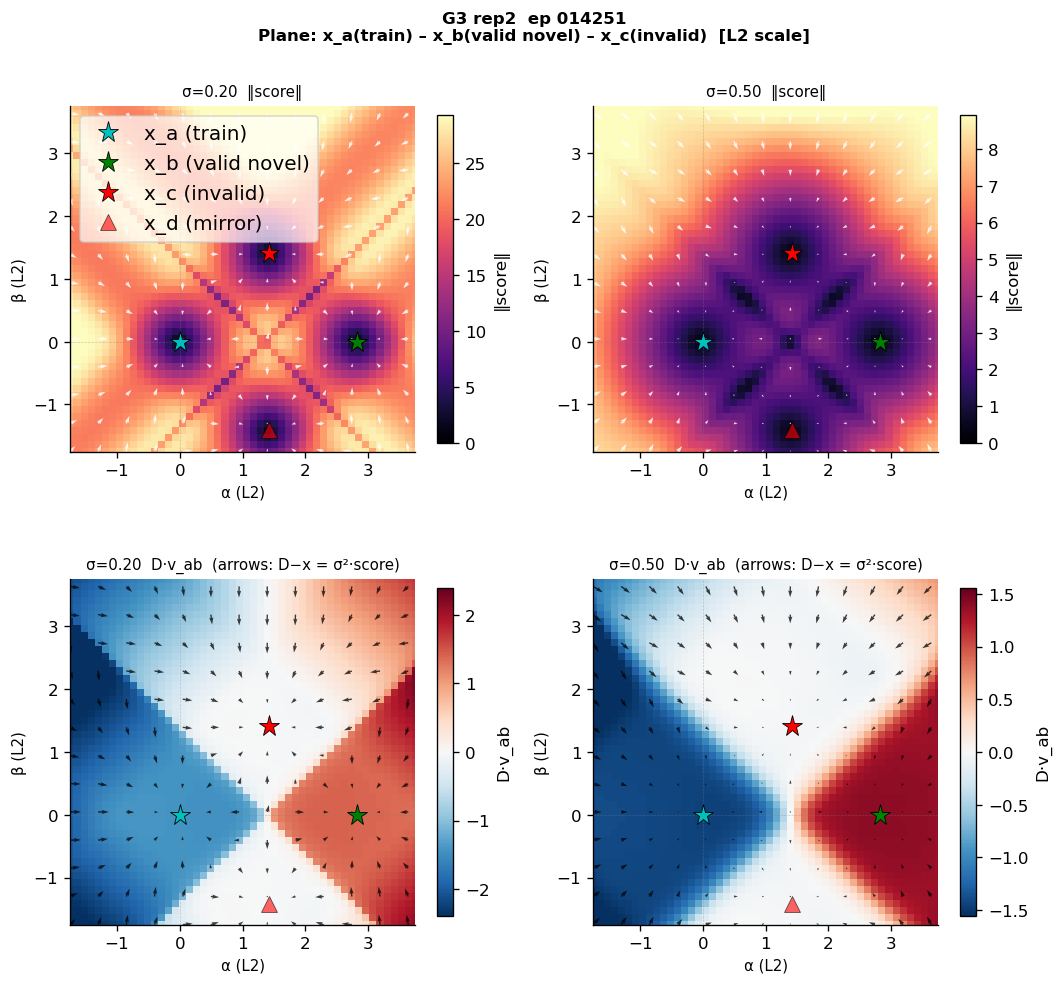

  Saved: 03_vector_field_ckpt_119377.png/pdf


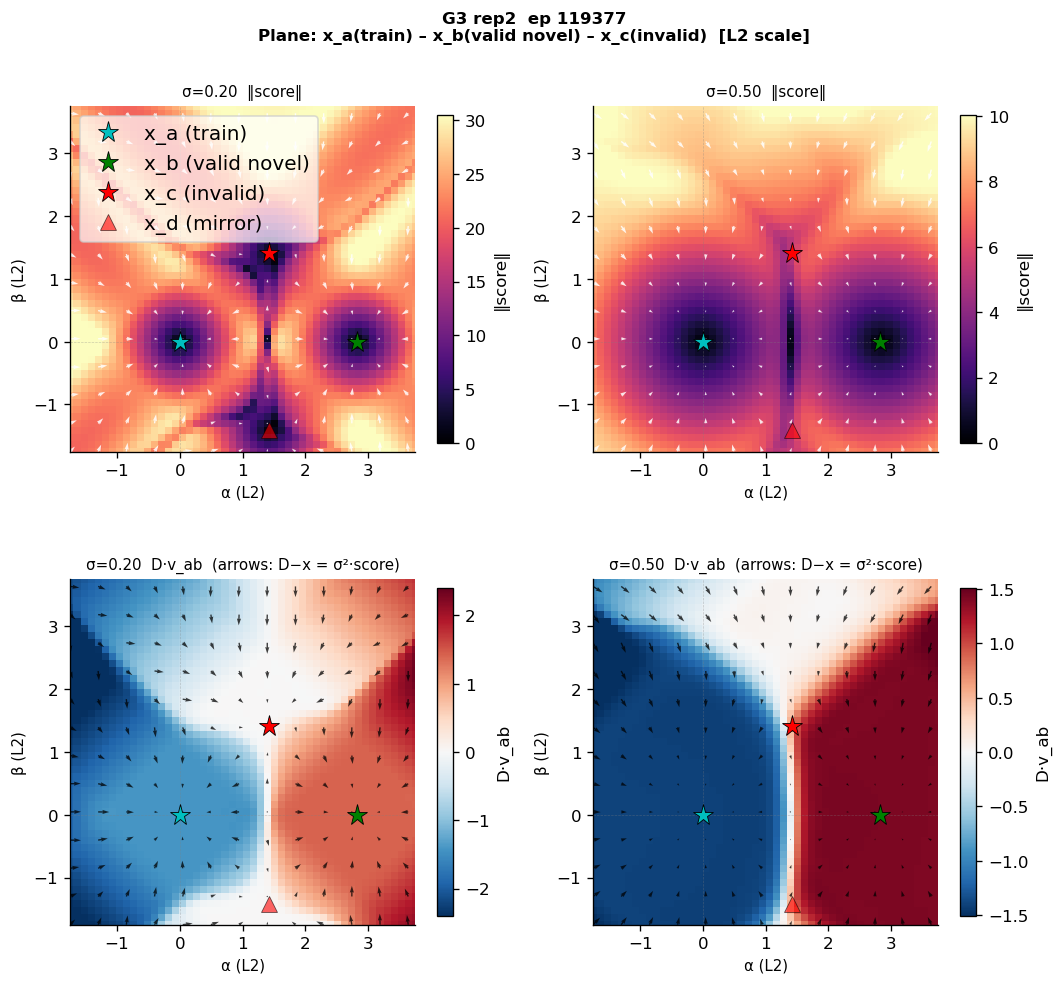

  Saved: 03_vector_field_ckpt_492388.png/pdf


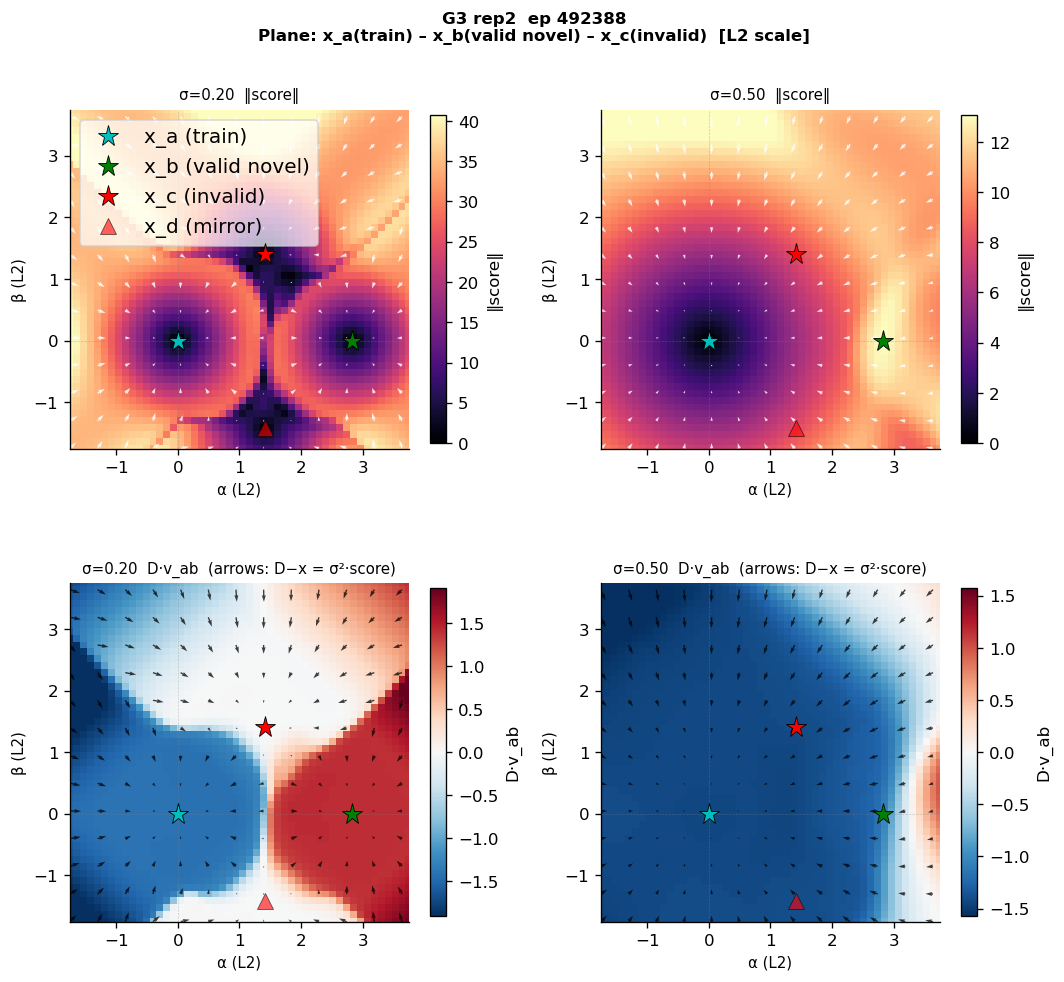

In [ ]:

# ── Config ────────────────────────────────────────────────────────────────────
EXP_NAME   = "DiT_mini_parity_N4096_D36_G3_even_rep2"
EXP_DIR    = os.path.join(DEFAULT_SAVEROOT, EXP_NAME)
CACHE_DIR  = os.path.join(EXP_DIR, "vector_field_cache")
DEVICE     = "cpu"
NGRID      = 50
PLANE_HASH = "191059703a35"
RANGE_TAG  = "a-1.75_3.75"

# ── Plane setup ───────────────────────────────────────────────────────────────
x_train = load_training_data(EXP_NAME).numpy()
x_a = x_train[0].copy()
x_b = x_a.copy(); x_b[0] *= -1; x_b[1] *= -1   # valid novel (Hamming-2, parity preserved)
x_c = x_a.copy(); x_c[0] *= -1                  # invalid (Hamming-1, parity broken)

ab = x_b - x_a; L_ab = float(np.linalg.norm(ab)); v_ab = ab / L_ab
ac = x_c - x_a
ac_perp = ac - ac.dot(v_ab) * v_ab
L_perp  = float(np.linalg.norm(ac_perp)); v_ac = ac_perp / L_perp
xc_alpha = float(ac.dot(v_ab))
xc_beta  = float(np.linalg.norm(ac_perp))

# Grid axes: fixed square range [-1.75, 3.75] on BOTH axes (matches cache)
alpha_ax = np.linspace(-1.75, 3.75, NGRID, dtype=np.float32)
beta_ax  = np.linspace(-1.75, 3.75, NGRID, dtype=np.float32)
A, B     = np.meshgrid(alpha_ax, beta_ax, indexing='ij')
# grid_x must be (n1, n2, D) for eval_field_on_grid
grid_x   = (x_a[None, None, :] +
            A[:, :, None] * v_ab[None, None, :] +
            B[:, :, None] * v_ac[None, None, :]).astype(np.float32)

print(f"L_ab={L_ab:.3f}  L_perp={L_perp:.3f}")
print(f"Markers: x_a=(0,0)  x_b=({L_ab:.2f},0)  x_c=({xc_alpha:.2f},{xc_beta:.2f})  x_d=({xc_alpha:.2f},{-xc_beta:.2f})")


# ── plot_ckpt (from 20260429_G3_vector_field_three_sample_plane.ipynb) ────────
def plot_ckpt(ckpt_label, sigmas=(0.2, 0.5, 1.0, 2.0)):
    """
    Two-row figure per sigma:
      Row 0: score magnitude heatmap + score arrows
      Row 1: D·v_ab heatmap + D_pull arrows

    ckpt_label: zero-padded epoch string, e.g. "000049"
    model=None is safe because eval_field_on_grid returns from cache immediately.
    """
    s = 4
    grid_sp = (alpha_ax[-1] - alpha_ax[0]) / len(alpha_ax)

    fig, axes = plt.subplots(2, len(sigmas), figsize=(4.5 * len(sigmas), 8.5))
    fig.suptitle(
        f"G3 rep2  ep {ckpt_label}\n"
        f"Plane: x_a(train) – x_b(valid novel) – x_c(invalid)  [L2 scale]",
        fontsize=10, fontweight='bold',
    )

    for col, sigma in enumerate(sigmas):
        res = eval_field_on_grid(
            None, grid_x, sigma, device=DEVICE,
            cache_dir=CACHE_DIR,
            cache_key=f"ep{ckpt_label}_{PLANE_HASH}_{RANGE_TAG}",
        )
        u_s, v_s       = project_to_basis(res['score'],  v_ab, v_ac)
        Du,  Dv        = project_to_basis(res['D'],      v_ab, v_ac)
        disp_u, disp_v = project_to_basis(res['D_pull'], v_ab, v_ac)

        # ── row 0: score magnitude + arrows ──────────────────────────────────
        ax   = axes[0][col]
        mag  = res['mag_score']
        vmax = np.percentile(mag, 95)
        im   = ax.pcolormesh(alpha_ax, beta_ax, mag.T, cmap='magma',
                             vmin=0, vmax=vmax, shading='auto', rasterized=True)
        plt.colorbar(im, ax=ax, shrink=0.75, label='‖score‖')
        ax.quiver(A[::s, ::s], B[::s, ::s], u_s[::s, ::s], v_s[::s, ::s],
                  color='white', alpha=0.85,
                  scale=vmax / (1.5 * grid_sp), scale_units='xy', angles='xy', width=0.004)
        ax.plot(0,        0,         'c*', ms=13, label='x_a (train)',       zorder=10, mec='k', mew=0.5)
        ax.plot(L_ab,     0,         'g*', ms=13, label='x_b (valid novel)', zorder=10, mec='k', mew=0.5)
        ax.plot(xc_alpha, xc_beta,   'r*', ms=13, label='x_c (invalid)',     zorder=10, mec='k', mew=0.5)
        ax.plot(xc_alpha, -xc_beta,  'r^', ms=10, label='x_d (mirror)',      zorder=10, mec='k', mew=0.5, alpha=0.6)
        ax.set_aspect('equal')
        ax.set_xlim(alpha_ax[0], alpha_ax[-1]); ax.set_ylim(beta_ax[0], beta_ax[-1])
        ax.set_xlabel('α (L2)', fontsize=9); ax.set_ylabel('β (L2)', fontsize=9)
        ax.set_title(f'σ={sigma:.2f}  ‖score‖', fontsize=9)
        ax.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
        ax.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
        if col == 0:
            ax.legend(fontsize=12, loc='upper left', framealpha=0.7)

        # ── row 1: D·v_ab + D_pull arrows ────────────────────────────────────
        ax   = axes[1][col]
        clim = np.percentile(np.abs(Du), 97)
        im2  = ax.pcolormesh(alpha_ax, beta_ax, Du.T, cmap='RdBu_r',
                             vmin=-clim, vmax=clim, shading='auto', rasterized=True)
        plt.colorbar(im2, ax=ax, shrink=0.75, label='D·v_ab')
        dscale = np.percentile(np.sqrt(disp_u**2 + disp_v**2), 90) / (1.5 * grid_sp)
        ax.quiver(A[::s, ::s], B[::s, ::s], disp_u[::s, ::s], disp_v[::s, ::s],
                  color='k', alpha=0.75,
                  scale=dscale, scale_units='xy', angles='xy', width=0.004)
        ax.plot(0,        0,         'c*', ms=13, zorder=10, mec='k', mew=0.5)
        ax.plot(L_ab,     0,         'g*', ms=13, zorder=10, mec='k', mew=0.5)
        ax.plot(xc_alpha, xc_beta,   'r*', ms=13, zorder=10, mec='k', mew=0.5)
        ax.plot(xc_alpha, -xc_beta,  'r^', ms=10, zorder=10, mec='k', mew=0.5, alpha=0.6)
        ax.set_aspect('equal')
        ax.set_xlim(alpha_ax[0], alpha_ax[-1]); ax.set_ylim(beta_ax[0], beta_ax[-1])
        ax.set_xlabel('α (L2)', fontsize=9); ax.set_ylabel('β (L2)', fontsize=9)
        ax.set_title(f'σ={sigma:.2f}  D·v_ab  (arrows: D−x = σ²·score)', fontsize=9)
        ax.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
        ax.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)

    plt.tight_layout()
    return fig


# ── Usage ─────────────────────────────────────────────────────────────────────
for epoch in [49, 14251, 119377, 492388]:
    fig = plot_ckpt(f"{epoch:06d}", sigmas=(0.2, 0.5,)) #1.0, 2.0
    savefig_both(fig, f'03_vector_field_ckpt_{epoch:06d}')
    plt.show()


In [ ]:
if False:
    # Reconstruct the plane geometry from training data
    x_train = load_training_data(EXP_NAME, saveroot=SAVEROOT).numpy()  # (N,D)

    # Anchors (must match what was used when generating the cache):
    x_a = x_train[0].copy()
    # x_b: valid novel — flip bits 0+1 within group-0 ((-1)²=+1, parity preserved)
    x_b = x_a.copy(); x_b[0] *= -1; x_b[1] *= -1
    # x_c: invalid — flip bit-0 only (breaks group-0 parity)
    x_c = x_a.copy(); x_c[0] *= -1

    # Verify plane hash matches cache
    computed_hash = make_plane_hash(x_a, x_b, x_c)
    print(f"Plane hash: {computed_hash}  (expect prefix: {PLANE_HASH})")
    assert computed_hash.startswith(PLANE_HASH), f"Hash mismatch! {computed_hash}"

    # Build L2-scaled basis
    ab = x_b - x_a
    ac = x_c - x_a
    L_ab = float(np.linalg.norm(ab)); v_ab = ab / L_ab
    ac_perp = ac - ac.dot(v_ab) * v_ab
    L_perp  = float(np.linalg.norm(ac_perp)); v_ac = ac_perp / L_perp

    margin = 1.75
    alpha_ax = np.linspace(-margin, L_ab + margin, NGRID)
    beta_ax  = np.linspace(-margin, L_perp + margin, NGRID)
    A, B = np.meshgrid(alpha_ax, beta_ax, indexing='ij')  # (NGRID, NGRID)

    # Marker positions
    xc_alpha = float(ac.dot(v_ab))
    xc_beta  = float(np.linalg.norm(ac_perp))

    xd_alpha = xc_alpha
    xd_beta = -xc_beta
    print(f"L_ab={L_ab:.2f}  L_perp={L_perp:.2f}")
    print(f"x_a @ (0,0)  x_b @ ({L_ab:.2f},0)  x_c @ ({xc_alpha:.2f},{xc_beta:.2f})")


## Panel 4 — DSM Loss σ∈[0.2, 2.0] vs Training Step

  Saved: 04_dsm_loss_sigma02_2_vs_step.png/pdf


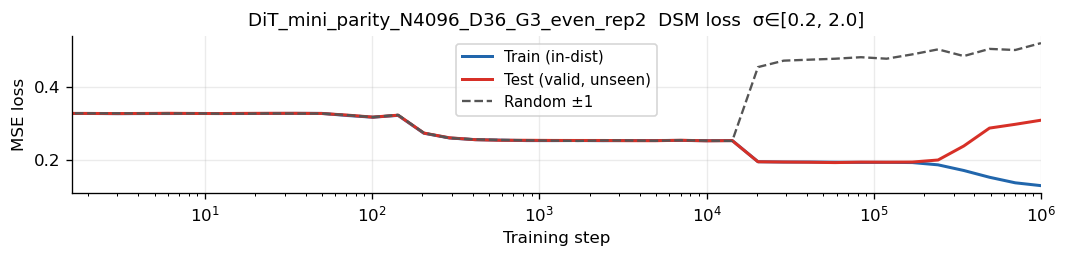

In [72]:
records = load_sigma_data(EXP_NAME)
steps = np.array([r['epoch'] for r in records])
sigma_grid = records[0]['sigma_grid']

# Only σ∈[0.2, 2.0] bin
smin, smax = 0.2, 2.0
fig, ax = plt.subplots(figsize=(9, 2.25))

SPLIT_STYLES_LOCAL = {
    'train':  dict(color='#2166ac', lw=1.8, label='Train (in-dist)'),
    'test':   dict(color='#d73027', lw=1.8, label='Test (valid, unseen)'),
    'random': dict(color='#555555', lw=1.4, ls='--', label='Random ±1'),
}
for split, style in SPLIT_STYLES_LOCAL.items():
    vals = np.array([bin_mean(r[f'loss_{split}'], sigma_grid, smin, smax) for r in records])
    mask = ~np.isnan(vals)
    ax.plot((steps + 1)[mask], vals[mask], **style)

ax.set_xlim(1.6, 1E6)
ax.set_xscale('log')
ax.set_xlabel('Training step', fontsize=10)
ax.set_ylabel('MSE loss', fontsize=10)
ax.set_title(f"{EXP_NAME}  DSM loss  σ∈[0.2, 2.0]", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
fig.tight_layout()
savefig_both(fig, '04_dsm_loss_sigma02_2_vs_step')
plt.show()

## Panel 5 — DSM Loss vs σ at Key Checkpoints (log-log)

  Saved: 05_dsm_loss_vs_sigma_loglog.png/pdf


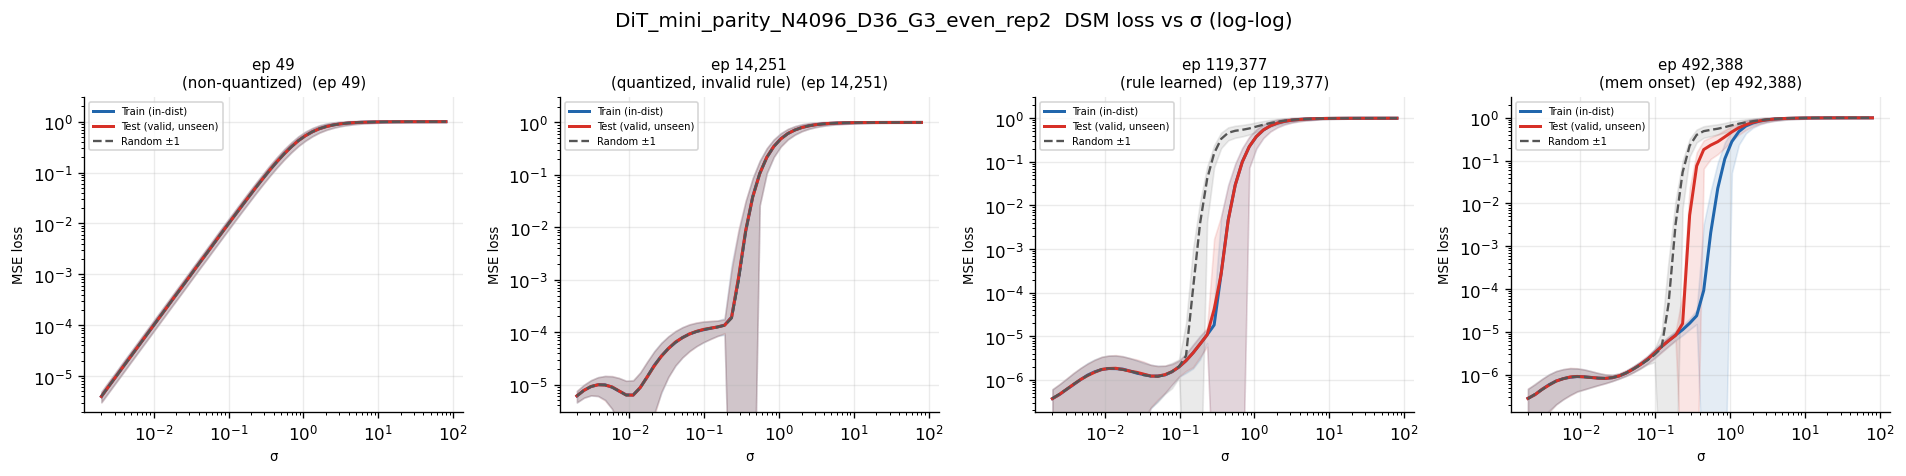

In [12]:
# ep 49, 14251, 119377, 492388  (indices 10, 26, 32, 36)
fig, axes = plt.subplots(1, len(SIGMA_LOSS_IDX), figsize=(16, 4))
ep_labels = ['ep 49\n(non-quantized)', 'ep 14,251\n(quantized, invalid rule)', 
             'ep 119,377\n(rule learned)', 'ep 492,388\n(mem onset)']
for ax, widx, lbl in zip(axes, SIGMA_LOSS_IDX, ep_labels):
    rec = records[widx]
    _draw_sigma_panel(ax, rec, lbl)
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)

fig.suptitle(f"{EXP_NAME}  DSM loss vs σ (log-log)", fontsize=12)
fig.tight_layout()
savefig_both(fig, '05_dsm_loss_vs_sigma_loglog')
plt.show()

## Panel 6 — Attractor Basin Profiles

  Saved: 06_attractor_basin_profiles_alternative.png/pdf


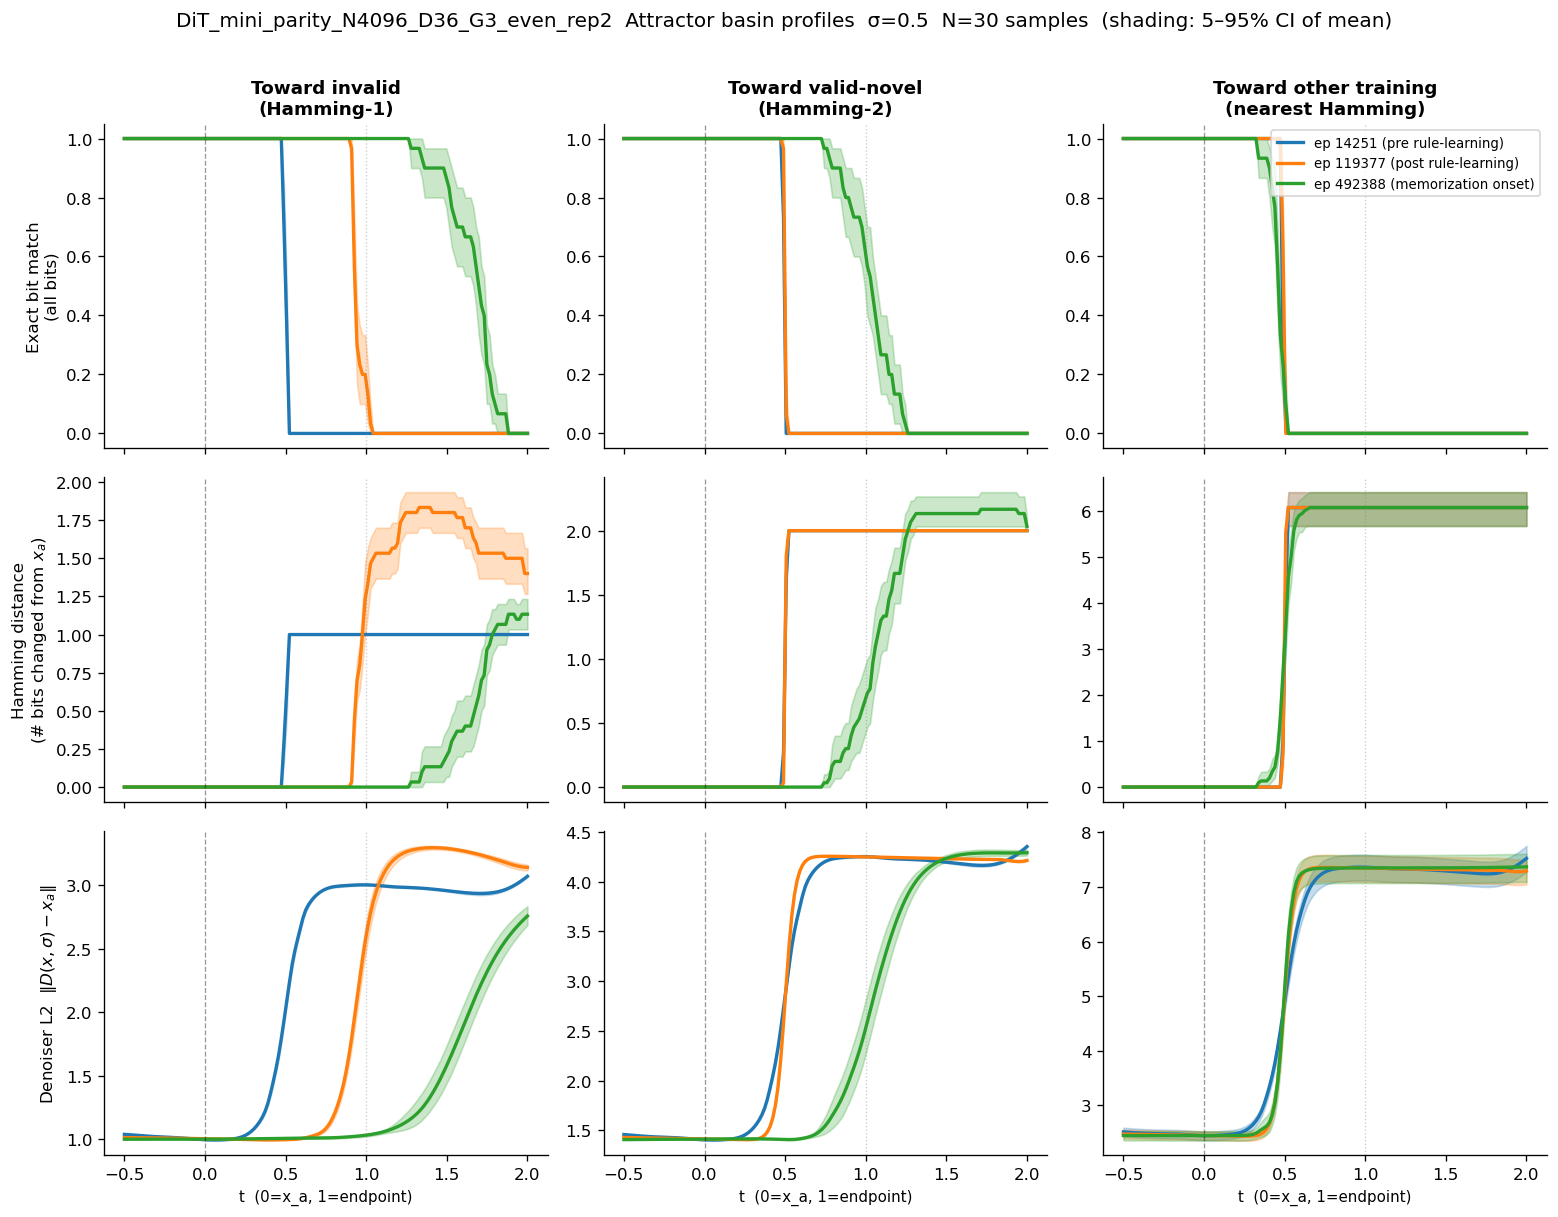

In [76]:
# Basin checkpoints
BASIN_EPOCHS = [14251, 119377, 492388]
BASIN_SIGMA  = 0.5
BASIN_N      = 30
BASIN_CACHE  = os.path.join(EXP_DIR, "basin_analysis", "line_cache")
BASIN_LABELS = {
    14251:   "ep 14251 (pre rule-learning)",
    119377:  "ep 119377 (post rule-learning)",
    492388: "ep 492388 (memorization onset)",
}
BASIN_COLORS = {14251: 'C0', 119377: 'C1', 492388: 'C2'}

BASIN_SIGMA = 0.5
fig = basin_plot_profiles(
    cache_dir=BASIN_CACHE,
    epochs=BASIN_EPOCHS,
    epoch_labels=BASIN_LABELS,
    epoch_colors=BASIN_COLORS,
    sigma=BASIN_SIGMA,
    n_samples=BASIN_N,
    title=(f"{EXP_NAME}  Attractor basin profiles  σ={BASIN_SIGMA}  "
           f"N={BASIN_N} samples  (shading: 5–95% CI of mean)"),
)
savefig_both(fig, '06_attractor_basin_profiles_alternative')
plt.show()